# W1D3 — Classification — Lab

**Week 1 · Day 3 · Foundations** · Lab

Monday's model produced a price. Today's produces a **probability**, and the whole lab is about what you
do with one. You will write the sigmoid yourself and reproduce this morning's 0.27, 0.50 and 0.73
exactly; fit a real classifier on telecom customers; draw the line it uses to separate them; find the
ten customers it is least sure about; and then move the decision threshold and count how many
predictions flip — having retrained nothing. You leave with `clf_baseline.json`.

Evaluation is deliberately thin today. Whether any of this is any *good* is tomorrow's lab, and
tomorrow's lab is the most important one of the week.

**Time budget:** ~115 minutes. Sections 1–2 are the lab; Section 3 is a stretch you may finish at home.

<div dir="rtl" align="right">

# الأسبوع ١ اليوم ٣ — التصنيف

**الأسبوع ١ · اليوم ٣ · الأساسيات** · معمل عملي

نموذج يوم الاثنين أنتج سعرًا. ونموذج اليوم يُنتج **احتمالًا**، والمعمل كله عن ماذا تفعل بالاحتمال. ستكتب
دالة السيجمويد بنفسك وتُعيد إنتاج قيم هذا الصباح ٠٫٢٧ و٠٫٥٠ و٠٫٧٣ تمامًا؛ ثم تدرّب مصنّفًا حقيقيًا على
عملاء اتصالات؛ وترسم الخط الذي يفصل بينهم؛ وتجد العملاء العشرة الأقل يقينًا لدى النموذج؛ ثم تحرّك عتبة
القرار وتَعُدّ كم تنبّؤًا انقلب — دون أن تعيد التدريب إطلاقًا. وستخرج بملف `clf_baseline.json`.

التقييم اليوم رقيق عن قصد. أما هل هذا كله **جيّد** فذاك معمل الغد، ومعمل الغد هو الأهم في الأسبوع.

**الزمن المتوقّع:** نحو ١١٥ دقيقة. القسمان الأول والثاني هما المعمل، والقسم الثالث إضافي يمكن إكماله في المنزل.

</div>

> **This is your lab notebook.** Work through the hints — they tell you what to do and where
> to look, not what to type. Stuck for more than ten minutes on one task? Open the `_guided`
> version. That is not cheating; sitting stuck in silence is the only mistake. The full
> solution is released at the end of the day.

<div dir="rtl" align="right">

> **هذا دفتر المعمل الخاص بك.** اعمل وفق الإرشادات — فهي تخبرك بما يجب فعله وأين تبحث، لا بما
> تكتبه حرفيًا. إذا توقّفت أكثر من عشر دقائق عند مهمة واحدة فافتح نسخة `_guided`؛ هذا ليس غشًّا،
> والخطأ الوحيد هو أن تبقى متوقّفًا بصمت. ويُنشر الحل الكامل في نهاية اليوم.

</div>

## Learning objectives

By the end of this lab you can:

- Write the sigmoid and say what it turns a score into, and what it does not.
- Fit `LogisticRegression` and read `predict_proba` rather than only `predict`.
- Draw a linear decision boundary over the data and judge whether a straight line is enough.
- Find the rows a model is least certain about, and explain why they are the interesting ones.
- Change a decision threshold and state, precisely, what changed and what did not.

<div dir="rtl" align="right">

## أهداف التعلّم

بنهاية هذا المعمل ستكون قادرًا على:

- كتابة دالة السيجمويد وتحديد ما الذي تحوّل إليه الدرجة، وما الذي لا تفعله.
- تدريب `LogisticRegression` وقراءة `predict_proba` لا الاكتفاء بـ`predict`.
- رسم حدّ قرار خطّي فوق البيانات والحكم هل يكفي الخط المستقيم.
- إيجاد الصفوف التي يقلّ يقين النموذج فيها، وشرح لماذا هي الصفوف المهمّة.
- تغيير عتبة القرار وتحديد ما الذي تغيّر وما الذي لم يتغيّر، بدقّة.

</div>

## About the data

**Dataset:** `telco_churn` — IBM's public telecom sample · CC0 (public domain) · 7,043 rows

One row is one postpaid customer. The label is `Churn`: did they leave the service. Twenty-six and a
half percent of them did, so a model that predicts "nobody leaves" is already right 73.5% of the time —
remember that number, it is the whole of tomorrow. Today you use two columns: `tenure`, how many months
they have been a customer, and `MonthlyCharges`, what they pay per month. Predicting churn is worth
doing because keeping a customer costs a fraction of winning a new one, and the people worth phoning are
the ones who have not left yet.

This is the dataset weeks 1 to 3 keep returning to. You will clean it in W2D3 and engineer features from
it in W2D4; today you only borrow two columns that are already numeric.

**Watch out:** `TotalCharges` is stored as **text**, not a number, and it is blank for the 11 customers
whose tenure is 0 — they were billed nothing because they had not been billed yet. You do not need that
column today; Section 3 is where it bites, and W2D3 is where you fix it properly.

**Note on the framing:** this morning's slides used a Saudi operator to make the idea concrete. The data
here is IBM's public sample, not Saudi data. The model does not care; you should know which is which.

<div dir="rtl" align="right">

## عن البيانات

**مجموعة البيانات:** `telco_churn` — عيّنة اتصالات عامة من IBM · رخصة CC0 (ملكية عامة) · ٧٬٠٤٣ صفًا

الصف الواحد عميل واحد بنظام الدفع الآجل. والتسمية هي `Churn`: هل غادر الخدمة. غادر ٢٦٫٥٪ منهم، ومعنى ذلك
أن نموذجًا يتنبّأ بأن «لا أحد يغادر» يكون مصيبًا في ٧٣٫٥٪ من الحالات — احفظ هذا الرقم، فهو موضوع الغد
كلّه. اليوم تستخدم عمودين: `tenure` وهو عدد أشهر بقاء العميل، و`MonthlyCharges` وهو ما يدفعه شهريًا.
والتنبّؤ بالمغادرة يستحق العناء لأن الاحتفاظ بعميل يكلّف جزءًا يسيرًا من كسب عميل جديد، ومن يستحق الاتصال
بهم هم من لم يغادروا بعد.

هذه هي المجموعة التي تعود إليها الأسابيع من الأول إلى الثالث. ستنظّفها في الأسبوع ٢ اليوم ٣ وتشتقّ منها
خصائص في الأسبوع ٢ اليوم ٤؛ أما اليوم فتستعير عمودين رقميين جاهزين فقط.

**انتبه:** العمود `TotalCharges` مخزّن **كنص** لا كرقم، وهو فارغ لدى أحد عشر عميلًا مدّة اشتراكهم صفر —
لم تُصدر لهم فاتورة بعد. لا تحتاج هذا العمود اليوم؛ والقسم الثالث هو موضع أثره، والأسبوع ٢ اليوم ٣ هو
موضع إصلاحه على وجهه.

**ملاحظة على السياق:** استخدمت شرائح الصباح مشغّلًا سعوديًا لتقريب الفكرة. أما البيانات هنا فهي عيّنة IBM
العامة لا بيانات سعودية. النموذج لا يفرّق، وأنت ينبغي أن تفرّق.

</div>

## Setup

Run the cell below first. It installs anything missing, fixes the random seed, finds the dataset, and
hands you the two feature columns and the label as plain NumPy arrays — no pandas wrangling today.

It also defines `probability_grid`, a helper for Task 2.3. Building a mesh grid is fiddly and it is not
today's lesson, so it is written for you.

<div dir="rtl" align="right">

## الإعداد

شغّل الخلية التالية أولًا. تُثبّت ما ينقص، وتُثبّت البذرة العشوائية، وتجد ملف البيانات، وتسلّمك عمودَي
الخصائص والتسمية كمصفوفات NumPy مباشرة — بلا معالجة بيانات اليوم.

كما تُعرّف `probability_grid`، وهي أداة مساعدة للمهمة ٢٫٣. بناء الشبكة النقطية عمل متشعّب وليس درس اليوم،
فكُتب لك.

</div>

In [15]:
# === AIEP portable setup — works locally (Miniconda + uv) and on Google Colab ===============
try:
    import aiep
except ImportError:
    import subprocess, sys
    from pathlib import Path
    # A clone that never ran `uv pip install -e shared/` still has the package on disk —
    # use it before reaching for the network. Colab (no clone) falls through to pip.
    _local = next((p / "shared" for p in [Path.cwd(), *Path.cwd().parents]
                   if (p / "shared" / "aiep").is_dir()), None)
    if _local:
        sys.path.insert(0, str(_local))
    else:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q",
                               "git+https://github.com/0xRush/AIEP_Olo_student.git#subdirectory=shared"])
    import aiep

from aiep.env import ensure, seed_everything, versions
from aiep.data import get_dataset, describe_dataset
from aiep.paths import ARTEFACT_DIR
from aiep.checks import check, check_close, report

ensure("scikit-learn", "matplotlib")
seed_everything(42)

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from aiep.viz import use_course_style
use_course_style()

DATA = get_dataset("telco_churn")
_df = pd.read_parquet(DATA)

FEATURES = ["tenure", "MonthlyCharges"]
X = _df[FEATURES].to_numpy(dtype=float)     # 7043 x 2 — months, and riyals-equivalent per month
y = (_df["Churn"] == "Yes").astype(int).to_numpy()   # 1 = the customer left


def probability_grid(model, X, steps=200, pad=1.0):
    """A mesh over the two feature columns, with the model's P(churn) at every point.

    Returns (xx, yy, probs) ready for ax.contourf / ax.contour. Written for you: the grid
    is plumbing, not the lesson.
    """
    x_min, x_max = X[:, 0].min() - pad, X[:, 0].max() + pad
    y_min, y_max = X[:, 1].min() - pad, X[:, 1].max() + pad
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, steps), np.linspace(y_min, y_max, steps))
    probs = model.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:, 1].reshape(xx.shape)
    return xx, yy, probs


print(describe_dataset("telco_churn"))
print(f"\nX {X.shape} -> {FEATURES} | churn rate {y.mean():.4f}")
print("\n", versions())

📁 telco_churn: using cached file at /content/aiep_data/telco_churn.parquet
telco_churn  (7043 rows, 0.2 MB)
  Source:  https://www.kaggle.com/datasets/blastchar/telco-customer-churn
  Licence: CC0 (public domain)
  Target:  Churn

  EN: Telecom customer records with a churn label. Mixed numeric and categorical columns, a genuinely imbalanced target (~27% churn), and enough messiness to carry the whole of weeks 1-3 without students restarting on a new dataset every day.
  AR: سجلات عملاء اتصالات مع عمود يوضّح مغادرة العميل للخدمة. أعمدة رقمية وفئوية مختلطة، وهدف غير متوازن فعليًا (نحو ٢٧٪)، وفيها من الفوضى ما يكفي لتغطية الأسابيع الثلاثة الأولى دون أن يبدأ الطلاب من مجموعة بيانات جديدة كل يوم.

  ⚠️  Watch out: TotalCharges is stored as text and is blank for customers with tenure = 0.
  ⚠️  انتبه: عمود TotalCharges مخزّن كنص ويكون فارغًا للعملاء الذين مدّة اشتراكهم صفر.

X (7043, 2) -> ['tenure', 'MonthlyCharges'] | churn rate 0.2654

 python 3.13.15 | numpy 2.1.3 | pandas 2.2.3 | sciki

## Section 1 — Warm-up: the sigmoid, by hand and in code  (≈25 min)

A linear model gives you a score that can be anything: −7, 0.2, 340. A probability has to sit between 0
and 1. The sigmoid is the function that turns the first into the second, and it is the only new piece of
mathematics in today's model.

<div dir="rtl" align="right">

## القسم الأول — التهيئة: السيجمويد يدويًا وبالشيفرة (نحو ٢٥ دقيقة)

النموذج الخطّي يعطيك درجة قد تكون أي شيء: ‎−٧ أو ٠٫٢ أو ٣٤٠. أما الاحتمال فيجب أن يقع بين صفر وواحد.
والسيجمويد هي الدالة التي تحوّل الأول إلى الثاني، وهي القطعة الرياضية الجديدة الوحيدة في نموذج اليوم.

</div>

### Task 1.1 — write `sigmoid(z)` and reproduce the lecture

This morning the room computed three probabilities by hand from `w = 2`, `b = −3` and three customers
at `x = 1`, `1.5` and `2`. The answers were **0.27, 0.50 and 0.73**.

Write the function and get the same three numbers. If you do not, the error is in your function, not in
the lecture.

<div dir="rtl" align="right">

### المهمة ١٫١ — اكتب `sigmoid(z)` وأعِد إنتاج المحاضرة

هذا الصباح حسبت القاعة ثلاثة احتمالات يدويًا من `w = 2` و`b = −3` وثلاثة عملاء عند `x = 1` و`1.5` و`2`.
وكانت الإجابات **٠٫٢٧ و٠٫٥٠ و٠٫٧٣**.

اكتب الدالة واحصل على الأرقام الثلاثة نفسها. فإن لم تحصل عليها فالخطأ في دالتك لا في المحاضرة.

</div>

In [16]:
# ────────────────────────────────────────────────────────────────────
# 1) The sigmoid of z is 1 divided by (1 plus e to the minus z). NumPy has the exponential.
# 2) Write it so it works on a whole array at once, not one number at a time — no loop.
# 3) Check it before you trust it: sigmoid(0) must be exactly 0.5, and a large negative
#    input must give something very close to 0.
# Search: "numpy exp sigmoid function vectorised"
# https://numpy.org/doc/stable/reference/generated/numpy.exp.html
#
# ١) سيجمويد z هي واحد مقسومًا على (واحد زائد e مرفوعًا لسالب z). والأسّ موجود في NumPy.
# ٢) اكتبها لتعمل على مصفوفة كاملة دفعة واحدة لا على رقم واحد في كل مرة — بلا حلقة.
# ٣) تحقّق منها قبل أن تثق بها: يجب أن تساوي sigmoid(0) القيمة ٠٫٥ تمامًا، وأن يعطي المدخل
#    السالب الكبير قيمة قريبة جدًا من الصفر.
# ابحث عن: "numpy exp sigmoid function vectorised"
# ────────────────────────────────────────────────────────────────────

# TODO: Write sigmoid(z) so it maps any number, or any array of numbers, into the range 0 to 1.
# مهمة: اكتب sigmoid(z) لتحوّل أي رقم، أو أي مصفوفة أرقام، إلى المدى بين صفر وواحد.
def sigmoid(z):
  return 1 / (1 + np.exp(-z))
lecture_w, lecture_b = 2.0, -3.0
lecture_x = np.array([1.0, 1.5, 2.0])
lecture_z = lecture_w * lecture_x + lecture_b
print("z       :", np.round(lecture_z, 4))
print("sigmoid :", np.round(sigmoid(lecture_z), 2))
print("sigmoid(0) =", sigmoid(0.0))

z       : [-1.  0.  1.]
sigmoid : [0.27 0.5  0.73]
sigmoid(0) = 0.5


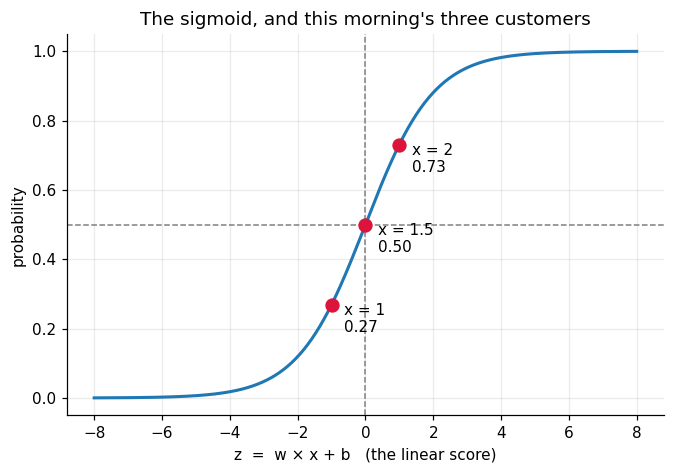

In [17]:
# Working code. Nothing to fill in here.
z_grid = np.linspace(-8, 8, 400)

fig, ax = plt.subplots()
ax.plot(z_grid, sigmoid(z_grid), linewidth=2)
ax.scatter(lecture_z, sigmoid(lecture_z), s=70, zorder=3, color="crimson")
for zz, label in zip(lecture_z, ["x = 1", "x = 1.5", "x = 2"]):
    ax.annotate(f"{label}\n{sigmoid(zz):.2f}", (zz, sigmoid(zz)),
                textcoords="offset points", xytext=(8, -18))
ax.axhline(0.5, linestyle="--", linewidth=1, color="grey")
ax.axvline(0.0, linestyle="--", linewidth=1, color="grey")
ax.set_xlabel("z  =  w × x + b   (the linear score)")
ax.set_ylabel("probability")
ax.set_title("The sigmoid, and this morning's three customers")
plt.show()

Two things to take from that picture.

The curve crosses 0.5 exactly where `z = 0` — which is to say, exactly where `w × x + b = 0`. That is
where the decision boundary will come from in Task 2.3; it is not a separate idea.

And the sigmoid is a **wrapper**. Inside it, `w × x + b` is the same linear model you fitted on Monday
and trained by hand yesterday. Nothing about the model changed. What changed is that its output is now
readable as a probability.

<div dir="rtl" align="right">

أمران يُؤخذان من هذه الصورة.

المنحنى يعبر ٠٫٥ عند `z = 0` بالضبط، أي عند `w × x + b = 0` بالضبط. ومن هنا سيأتي حدّ القرار في المهمة
٢٫٣؛ وليست فكرة منفصلة.

والسيجمويد **غلاف**. وداخله `w × x + b` هو النموذج الخطّي نفسه الذي درّبته يوم الاثنين وحسبته بيدك أمس.
لم يتغيّر شيء في النموذج. الذي تغيّر أن مخرجه صار يُقرأ كاحتمال.

</div>

## Section 2 — Core: a real classifier, and its probabilities  (≈60 min)

This is the lab. Each task below has a goal; you write the code.

<div dir="rtl" align="right">

## القسم الثاني — الأساسي: مصنّف حقيقي واحتمالاته (نحو ٦٠ دقيقة)

هذا هو صلب المعمل. لكل مهمة أدناه هدف محدّد، وأنت من يكتب الشيفرة.

</div>

### Task 2.1 — split, then fit

Same split as Monday, with one addition: **stratify on the label**. Churn is 26.5% of the data, and a
random split can easily hand you a test set with a different rate, which would make every number you
report today slightly dishonest.

Then fit `LogisticRegression` on the two features.

<div dir="rtl" align="right">

### المهمة ٢٫١ — قسّم ثم درّب

التقسيم نفسه كيوم الاثنين، بإضافة واحدة: **التقسيم الطبقي على التسمية**. المغادرون ٢٦٫٥٪ من البيانات،
والتقسيم العشوائي قد يعطيك مجموعة اختبار بنسبة مختلفة، فتصبح كل أرقامك اليوم غير أمينة قليلًا.

ثم درّب `LogisticRegression` على الخاصيتين.

</div>

In [18]:
# ────────────────────────────────────────────────────────────────────
# 1) Keep 20% for testing, with random_state=42 so tomorrow's run matches today's.
# 2) The churn rate must survive the split — look up what the "stratify" argument does.
# 3) Then fit a logistic regression on the training half. The defaults are fine.
# 4) Print the churn rate in both halves to prove the stratify worked.
# Search: "sklearn train_test_split stratify LogisticRegression fit"
# https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html
#
# ١) احتفظ بـ٢٠٪ للاختبار مع random_state=42 ليطابق تشغيل الغد تشغيل اليوم.
# ٢) يجب أن تبقى نسبة المغادرين بعد التقسيم — ابحث عن معنى الوسيط "stratify".
# ٣) ثم درّب انحدارًا لوجستيًا على نصف التدريب. القيم الافتراضية كافية.
# ٤) اطبع نسبة المغادرين في النصفين لتثبت أن التقسيم الطبقي عمل.
# ابحث عن: "sklearn train_test_split stratify LogisticRegression fit"
# ────────────────────────────────────────────────────────────────────

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
# TODO: Split 80/20 keeping the churn rate in both halves, then fit LogisticRegression on the training half.
# مهمة: قسّم ٨٠٪ / ٢٠٪ مع الحفاظ على نسبة المغادرين في النصفين، ثم درّب LogisticRegression على نصف التدريب.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
model = LogisticRegression()
model.fit(X_train, y_train)

print(f"train {X_train.shape[0]:,} rows, churn {y_train.mean():.4f}")
print(f"test  {X_test.shape[0]:,} rows, churn {y_test.mean():.4f}")
for name, coefficient in zip(FEATURES, model.coef_[0]):
    print(f"coefficient for {name:<16} {coefficient:+.5f}")
print(f"intercept   : {model.intercept_[0]:.5f}")

train 5,634 rows, churn 0.2654
test  1,409 rows, churn 0.2654
coefficient for tenure           -0.05428
coefficient for MonthlyCharges   +0.03354
intercept   : -1.85228


The signs are worth reading before you go on. `tenure` has a **negative** coefficient: the longer someone
has been a customer, the less likely they are to leave. `MonthlyCharges` has a **positive** one: the more
they pay, the more likely. Neither is a surprise, and that is the point — a model whose coefficients
contradict everything the business knows is usually a bug, not an insight.

The two magnitudes, 0.054 and 0.034, cannot be compared. Months and dollars are different units, and
yesterday's lab is the reason you know that.

<div dir="rtl" align="right">

تستحق الإشارات قراءة قبل المتابعة. معامل `tenure` **سالب**: كلما طالت مدّة العميل قلّ احتمال مغادرته.
ومعامل `MonthlyCharges` **موجب**: كلما زاد ما يدفعه زاد الاحتمال. وليس في أيّهما مفاجأة، وهذا هو المقصد —
فالنموذج الذي تناقض معاملاته كل ما يعرفه القطاع يكون خطأً في الغالب لا اكتشافًا.

أما المقداران ٠٫٠٥٤ و٠٫٠٣٤ فلا يقبلان المقارنة. الأشهر والدولارات وحدتان مختلفتان، ومعمل الأمس هو سبب
معرفتك بذلك.

</div>

### Task 2.2 — look at the probabilities, not the labels

`predict` gives you 0s and 1s and throws away everything interesting. `predict_proba` gives you the
number the model actually computed.

Get the churn probability for every test customer, then look at how those probabilities are spread out:
print the smallest, the largest, the mean and the median, and draw a histogram.

<div dir="rtl" align="right">

### المهمة ٢٫٢ — انظر إلى الاحتمالات لا إلى التسميات

الدالة `predict` تعطيك أصفارًا وآحادًا وتُهدر كل ما هو مثير للاهتمام. أما `predict_proba` فتعطيك الرقم
الذي حسبه النموذج فعلًا.

احسب احتمال المغادرة لكل عميل في مجموعة الاختبار، ثم انظر كيف تتوزّع هذه الاحتمالات: اطبع أصغرها وأكبرها
ومتوسّطها ووسيطها، وارسم مدرّجًا تكراريًا.

</div>


min    : 0.0060
max    : 0.8230
mean   : 0.2688
median : 0.2098


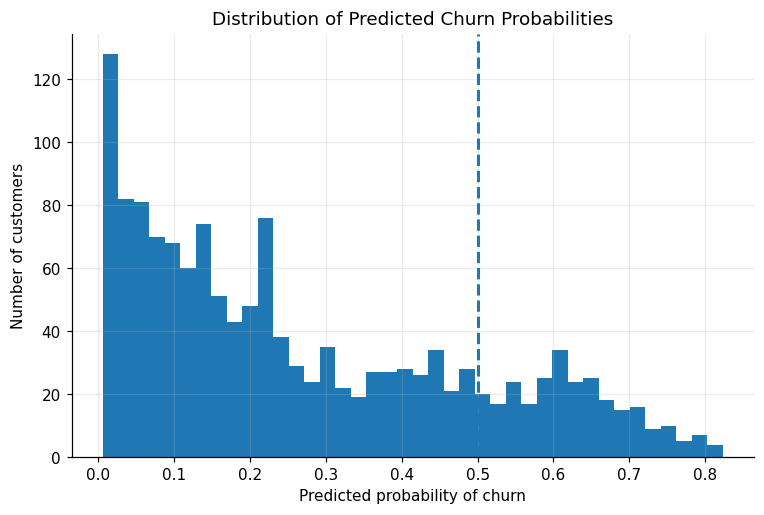

In [19]:
# ────────────────────────────────────────────────────────────────────
# 1) predict_proba returns one column per class. You want the probability of class 1 —
#    the customer leaving — which is the second column.
# 2) Store it as `probs`; every later task uses it.
# 3) Print min, max, mean and median, then draw a histogram with about 40 bins.
# 4) Mark 0.5 on the histogram with a vertical line so you can see how much sits above it.
# Search: "sklearn predict_proba second column positive class"
#
# ١) تُرجع predict_proba عمودًا لكل فئة. وأنت تريد احتمال الفئة ١ — أي مغادرة العميل —
#    وهو العمود الثاني.
# ٢) خزّنه باسم `probs`؛ فكل مهمة تالية تستخدمه.
# ٣) اطبع الأصغر والأكبر والمتوسّط والوسيط، ثم ارسم مدرّجًا تكراريًا بنحو ٤٠ فئة.
# ٤) علّم القيمة ٠٫٥ على المدرّج بخط رأسي لترى كم يقع فوقها.
# ابحث عن: "sklearn predict_proba second column positive class"
# ────────────────────────────────────────────────────────────────────

# TODO: Get P(churn) for every test row into `probs`, summarise its spread, and plot it.
# مهمة: احسب احتمال المغادرة لكل صف اختبار في `probs`، ولخّص انتشاره، وارسمه.
probs = model.predict_proba(X_test)[:, 1]

# Summarise the probabilities
print(f"\nmin    : {probs.min():.4f}")
print(f"max    : {probs.max():.4f}")
print(f"mean   : {probs.mean():.4f}")
print(f"median : {np.median(probs):.4f}")


# Plot histogram
plt.figure(figsize=(8, 5))

plt.hist(probs, bins=40)

# Mark the 0.5 threshold
plt.axvline(
    0.5,
    linestyle="--",
    linewidth=2
)

plt.xlabel("Predicted probability of churn")
plt.ylabel("Number of customers")
plt.title("Distribution of Predicted Churn Probabilities")

plt.show()

The model never says 1.0, and it never says 0.0. Its most confident prediction on this test set is 0.82,
and two features are the reason: you have told it how long someone has been a customer and what they
pay, and nothing else. It cannot be certain because it does not know enough to be.

Notice also how much of the mass sits below 0.5. At the default threshold, most of these customers are
predicted "will not leave" — including plenty who will.

<div dir="rtl" align="right">

النموذج لا يقول ١٫٠ أبدًا، ولا يقول ٠٫٠ أبدًا. وأكثر تنبّؤاته ثقة على مجموعة الاختبار هذه هو ٠٫٨٢،
والسبب خاصيتان اثنتان: أخبرته بمدّة بقاء العميل وبما يدفعه ولا شيء غير ذلك. فهو لا يستطيع أن يكون واثقًا
لأنه لا يعرف ما يكفي لذلك.

ولاحظ أيضًا كم من الكتلة يقع تحت ٠٫٥. فعند العتبة الافتراضية يُتنبَّأ لأغلب هؤلاء بأنهم «لن يغادروا»،
ومنهم كثيرون سيغادرون.

</div>

### Task 2.3 — draw the boundary

The model separates the two classes with a straight line: everywhere `tenure × w₁ + charges × w₂ + b`
is zero. Draw it.

Use `probability_grid(model, X_test)` from the setup cell — it hands you `xx`, `yy` and the model's
probability at every point on a mesh. Shade the probability underneath, scatter the test customers on
top coloured by whether they actually churned, and draw the 0.5 contour as the boundary itself.

<div dir="rtl" align="right">

### المهمة ٢٫٣ — ارسم الحدّ

يفصل النموذج بين الفئتين بخط مستقيم: حيث يكون `tenure × w₁ + charges × w₂ + b` مساويًا صفرًا. ارسمه.

استخدم `probability_grid(model, X_test)` من خلية الإعداد — فهي تعطيك `xx` و`yy` واحتمال النموذج عند كل
نقطة على الشبكة. ظلّل الاحتمال تحتها، وانثر عملاء الاختبار فوقها ملوّنين بحسب مغادرتهم الفعلية، وارسم
كنتور القيمة ٠٫٥ ليكون الحدّ نفسه.

</div>

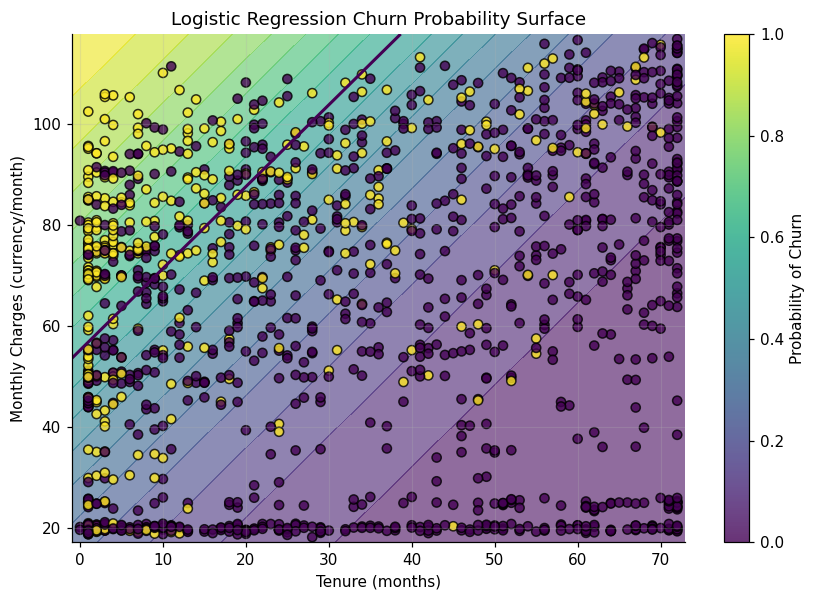

In [20]:
# ────────────────────────────────────────────────────────────────────
# 1) Call probability_grid(model, X_test) — it returns xx, yy and the probabilities.
# 2) Shade with contourf, then draw the single 0.5 contour on top with contour(levels=[0.5]).
# 3) Scatter the test customers: column 0 on x, column 1 on y, coloured by y_test.
# 4) Label the axes in their real units — months and currency per month. A plot nobody can
#    read is not evidence of anything.
# Search: "matplotlib contourf decision boundary scatter classes"
# https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.contourf.html
#
# ١) استدعِ probability_grid(model, X_test) — تُرجع xx وyy والاحتمالات.
# ٢) ظلّل بـcontourf، ثم ارسم كنتور القيمة ٠٫٥ وحده فوقها بـcontour(levels=[0.5]).
# ٣) انثر عملاء الاختبار: العمود صفر على المحور الأفقي، والعمود واحد على الرأسي،
#    وبلوّن بحسب y_test.
# ٤) سمِّ المحورين بوحدتيهما الحقيقيتين — أشهر ومبلغ شهري. فالرسم الذي لا يُقرأ ليس دليلًا على شيء.
# ابحث عن: "matplotlib contourf decision boundary scatter classes"
# ────────────────────────────────────────────────────────────────────

# TODO: Plot the model's probability surface over the two features, with the 0.5 boundary marked and the test customers scattered on top by their true label.
# مهمة: ارسم سطح احتمالات النموذج فوق الخاصيتين، مع تعليم حدّ ٠٫٥ ونثر عملاء الاختبار فوقه بتسميتهم الحقيقية.
# Get the probability grid
xx, yy, probabilities = probability_grid(model, X_test)

# Create the plot
plt.figure(figsize=(9, 6))

# Shade the probability surface
plt.contourf( xx, yy,probabilities, levels=20, alpha=0.6)

# Draw the 0.5 decision boundary
plt.contour(
    xx,
    yy,
    probabilities,
    levels=[0.5],
    linewidths=2
)

# Scatter the test customers
plt.scatter(
    X_test[:, 0],
    X_test[:, 1],
    c=y_test, edgecolors="black", alpha=0.8)

# Label axes in real units
plt.xlabel("Tenure (months)")
plt.ylabel("Monthly Charges (currency/month)")

plt.title("Logistic Regression Churn Probability Surface")

plt.colorbar(label="Probability of Churn")

plt.show()

Look at the two colours, and be honest about what you see: they are not separable by that line. Red
points sit deep in the blue region and blue points deep in the red. No straight line drawn on these two
axes could do much better, because the classes genuinely overlap — two customers with the same tenure
and the same bill, one of whom left and one of whom stayed, is not a contradiction. It is a customer
base.

That is a limit of the *model shape*, not of the fitting. In W3D1 you meet decision trees, which can
carve this plane into boxes instead of halves, and the first thing you will do is come back to a picture
like this one.

<div dir="rtl" align="right">

انظر إلى اللونين وكن صريحًا فيما ترى: لا يفصلهما ذلك الخط. فثمّة نقاط حمراء في عمق المنطقة الزرقاء
وزرقاء في عمق الحمراء. ولا يستطيع أي خط مستقيم على هذين المحورين أن يصنع أفضل من ذلك كثيرًا، لأن الفئتين
متداخلتان فعلًا — وعميلان بالمدّة نفسها والفاتورة نفسها، غادر أحدهما وبقي الآخر، ليس تناقضًا. إنه واقع
قاعدة العملاء.

وهذا قيد في **شكل النموذج** لا في التدريب. وفي الأسبوع ٣ اليوم ١ تلقى الأشجار القرارية التي تقسّم هذا
المستوى إلى صناديق بدل نصفين، وأول ما ستفعله هو العودة إلى صورة كهذه.

</div>

### Task 2.4 — the ten customers it is least sure about

A probability of 0.02 and a probability of 0.49 both round to "will not leave", and they are not remotely
the same claim. The rows near 0.5 are where the model is admitting it does not know.

Find the ten test customers whose probability is closest to 0.5, and show them with their tenure, their
monthly charge, their probability, and whether they actually churned.

<div dir="rtl" align="right">

### المهمة ٢٫٤ — العملاء العشرة الأقل يقينًا

الاحتمال ٠٫٠٢ والاحتمال ٠٫٤٩ كلاهما يُقرَّب إلى «لن يغادر»، وليسا الدعوى نفسها إطلاقًا. والصفوف القريبة
من ٠٫٥ هي التي يعترف فيها النموذج بأنه لا يعرف.

جِد عملاء الاختبار العشرة الأقرب احتمالًا إلى ٠٫٥، واعرضهم بمدّتهم ورسمهم الشهري واحتمالهم وهل غادروا فعلًا.

</div>

In [21]:
# ────────────────────────────────────────────────────────────────────
# 1) "Closest to 0.5" is smallest absolute distance from 0.5. Compute that distance per row.
# 2) You need the positions of the ten smallest, not the values — look for an argument-sort.
# 3) Build a small DataFrame with the two features, the probability, and the true label,
#    so the ten rows are readable side by side.
# 4) Count how many of the ten actually churned before you read on.
# Search: "numpy argsort smallest n indices"
#
# ١) «الأقرب إلى ٠٫٥» يعني أصغر مسافة مطلقة عن ٠٫٥. احسب هذه المسافة لكل صف.
# ٢) تريد مواضع العشرة الأصغر لا قيمها — ابحث عن ترتيب يُرجع الفهارس.
# ٣) ابنِ DataFrame صغيرًا فيه الخاصيتان والاحتمال والتسمية الحقيقية،
#    لتُقرأ الصفوف العشرة جنبًا إلى جنب.
# ٤) عُدّ كم واحدًا من العشرة غادر فعلًا قبل أن تكمل القراءة.
# ابحث عن: "numpy argsort smallest n indices"
# ────────────────────────────────────────────────────────────────────

# TODO: Show the ten test customers whose P(churn) is closest to 0.5, with their true outcome.
# مهمة: اعرض عملاء الاختبار العشرة الأقرب احتمالًا إلى ٠٫٥ مع نتيجتهم الحقيقية.
# Distance from 0.5 for each prediction
distance = np.abs(probs - 0.5)

# Get the indices of the 10 smallest distances
closest_indices = np.argsort(distance)[:10]

# Build a readable DataFrame
uncertain = pd.DataFrame({
    FEATURES[0]: X_test[closest_indices, 0],
    FEATURES[1]: X_test[closest_indices, 1],
    "probability": probs[closest_indices],
    "actually_churned": y_test[closest_indices]
})

# Show the 10 most uncertain customers
print(uncertain.to_string(index=False))

# Count how many actually churned
print(uncertain.to_string(index=False))
print(f"\n{int(uncertain['actually_churned'].sum())} of these 10 actually churned")

 tenure  MonthlyCharges  probability  actually_churned
   19.0           86.00     0.500202                 1
   15.0           79.40     0.499141                 1
   28.0          100.35     0.498399                 0
   25.0           95.90     0.501795                 1
    4.0           61.45     0.497898                 1
    9.0           69.50     0.497548                 0
    7.0           66.85     0.502467                 0
   22.0           90.50     0.497225                 1
    8.0           68.55     0.503152                 0
    9.0           69.40     0.496710                 0
 tenure  MonthlyCharges  probability  actually_churned
   19.0           86.00     0.500202                 1
   15.0           79.40     0.499141                 1
   28.0          100.35     0.498399                 0
   25.0           95.90     0.501795                 1
    4.0           61.45     0.497898                 1
    9.0           69.50     0.497548                 0
    7.0   

Five of the ten left and five stayed. That is not the model failing — it is the model being right about
its own ignorance. These customers are all in their first two years — four to twenty-eight months in — paying in
the upper half of the price range, and on the evidence of two columns there is genuinely nothing to
choose between them.

This is where a real retention team would spend its money: not on the customers the model is sure about,
but on the ones sitting on the line, where a phone call might change the answer.

<div dir="rtl" align="right">

غادر خمسة من العشرة وبقي خمسة. وليس هذا فشلًا للنموذج، بل إصابة منه في تقدير جهله. فهؤلاء العملاء جميعًا في أول
عامَين من الاشتراك — بين أربعة أشهر وثمانية وعشرين شهرًا — ويدفعون في النصف الأعلى من مدى الأسعار،
وبدلالة عمودين اثنين لا يوجد فعلًا ما يرجّح أحدهما.

وهنا يُنفق فريق الاحتفاظ بالعملاء ماله حقًا: لا على من يوقن النموذج بشأنهم، بل على من يقفون على الخط،
حيث قد تغيّر مكالمة واحدة الإجابة.

</div>

### Task 2.5 — move the threshold, retrain nothing

0.5 is not part of the model. It is a default someone chose, and you can choose differently.

Count how many test customers are flagged as "will churn" at thresholds 0.3, 0.5 and 0.7, and how many
predictions **flip** relative to 0.5. Then write down, in the cell after, the one sentence this task
exists for.

<div dir="rtl" align="right">

### المهمة ٢٫٥ — حرّك العتبة، ولا تُعِد التدريب

العتبة ٠٫٥ ليست جزءًا من النموذج. إنها قيمة افتراضية اختارها أحدهم، ويمكنك أن تختار غيرها.

عُدّ كم عميل اختبار يُصنَّف «سيغادر» عند العتبات ٠٫٣ و٠٫٥ و٠٫٧، وكم تنبّؤًا **ينقلب** مقارنةً بـ٠٫٥. ثم
اكتب في الخلية التالية الجملة التي وُجدت هذه المهمة من أجلها.

</div>

In [39]:
# ────────────────────────────────────────────────────────────────────
# 1) A threshold turns probabilities into predictions: flagged when probs >= threshold.
# 2) Count the flagged, and report them as a share of the test set too — 263 means nothing
#    on its own.
# 3) A flip is a row whose prediction differs from the prediction at 0.5. Comparing two
#    boolean arrays with != gives you exactly that.
# 4) Do NOT call fit anywhere in this cell.
# Search: "numpy boolean array compare count nonzero"
#
# ١) العتبة تحوّل الاحتمالات إلى تنبّؤات: يُعلَّم الصف حين probs >= threshold.
# ٢) عُدّ المعلَّمين واذكر نسبتهم من مجموعة الاختبار أيضًا — فالرقم ٢٦٣ وحده
#    لا يعني شيئًا.
# ٣) الانقلاب صف يختلف تنبّؤه عن تنبّؤه عند ٠٫٥. ومقارنة مصفوفتين منطقيتين بـ!=
#    تعطيك ذلك تمامًا.
# ٤) لا تستدعِ fit في هذه الخلية إطلاقًا.
# ابحث عن: "numpy boolean array compare count nonzero"
# ────────────────────────────────────────────────────────────────────

THRESHOLDS = [0.3, 0.5, 0.7]
# TODO: For each threshold, report how many customers are flagged, their share of the test set, and how many predictions differ from the ones at 0.5.
# مهمة: لكل عتبة، اذكر عدد العملاء المعلَّمين ونسبتهم من مجموعة الاختبار، وكم تنبّؤًا يختلف عن تنبّؤات ٠٫٥.

# Predictions using the reference threshold 0.5
baseline_predictions = probs >= 0.5

threshold_rows = []

for threshold in THRESHOLDS:
    predictions = probs >= threshold

    flagged = int(np.sum(predictions))
    flagged_rate = flagged / len(y_test)

    flips_vs_0_5 = int(np.sum(predictions != baseline_predictions))

    threshold_rows.append({
        "threshold": threshold,
        "flagged": flagged,
        "flagged_rate": flagged_rate,
        "flips_vs_0.5": flips_vs_0_5
    })

thresholds_table = pd.DataFrame(threshold_rows)

print(thresholds_table.to_string(index=False))
print(f"\ntest set size: {len(y_test):,} | "
      f"customers who actually churned: {int(y_test.sum()):,}")

 threshold  flagged  flagged_rate  flips_vs_0.5
       0.3      527      0.374024           264
       0.5      263      0.186657             0
       0.7       51      0.036196           212

test set size: 1,409 | customers who actually churned: 374


Two hundred and sixty-four predictions changed between 0.3 and 0.5. Two hundred and twelve changed
between 0.5 and 0.7. **Nothing was retrained.** The coefficients are the same coefficients, the
probabilities are the same probabilities, and the model has not learned or forgotten anything. All that
moved is the line you drew across its output.

Write that sentence somewhere you will find it again. It is the single most common confusion about
classifiers, and it is worth being immune to it by Thursday, when you have to choose a threshold and
defend the choice.

<div dir="rtl" align="right">

انقلب مئتان وأربعة وستون تنبّؤًا بين ٠٫٣ و٠٫٥، ومئتان واثنا عشر بين ٠٫٥ و٠٫٧. **ولم يُعَد التدريب
إطلاقًا.** المعاملات هي المعاملات نفسها، والاحتمالات هي الاحتمالات نفسها، ولم يتعلّم النموذج شيئًا ولم
ينسَ شيئًا. كل ما تحرّك هو الخط الذي رسمته عبر مخرجه.

اكتب هذه الجملة في موضع تعود إليه. فهي أشيع لبس في المصنّفات، ويستحق أن تكون في مأمن منه قبل الخميس، حين
يلزمك اختيار عتبة والدفاع عن اختيارك.

</div>

## Section 3 — Stretch: more columns, and what they buy  (≈30 min)

Open-ended, and lower expectation of completeness. This is where today's skill meets your capstone.

Refit on **every** numeric column instead of two: `tenure`, `MonthlyCharges`, `SeniorCitizen`, and
`TotalCharges`. That last one is stored as text and blank for 11 customers, so you have to deal with it
before it will fit — which is a small preview of W2D3.

Then compare the accuracy against your two-feature model, and answer the question below.

**Link to your capstone:** you will face this exact trade-off. A model you can draw is a model you can
explain to a stakeholder; a model with forty features is usually slightly better and completely opaque.
Knowing what the extra accuracy cost you is part of the job.

<div dir="rtl" align="right">

## القسم الثالث — الإضافي: أعمدة أكثر، وما تشتريه (نحو ٣٠ دقيقة)

قسم مفتوح، ولا يُتوقّع إكماله بالكامل. هنا تلتقي مهارة اليوم بمشروع تخرّجك.

أعِد التدريب على **كل** الأعمدة الرقمية بدل عمودين: `tenure` و`MonthlyCharges` و`SeniorCitizen`
و`TotalCharges`. والأخير مخزّن كنص وفارغ لدى أحد عشر عميلًا، فعليك معالجته قبل أن يقبله النموذج — وهذه
لمحة صغيرة من الأسبوع ٢ اليوم ٣.

ثم قارن الدقة بنموذج الخاصيتين، وأجب عن السؤال أدناه.

**الصلة بمشروعك:** ستواجه هذه المفاضلة بعينها. فالنموذج الذي يمكنك رسمه نموذج يمكنك شرحه لصاحب القرار،
والنموذج بأربعين خاصية أفضل قليلًا في العادة ومُعتِم تمامًا. ومعرفة ثمن الدقة الزائدة جزء من العمل.

</div>

In [40]:
import pandas as pd
import numpy as np

# Load the dataset
df = pd.read_parquet(DATA)

# Convert TotalCharges from text to numeric
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

# The 11 blank TotalCharges belong to customers with tenure = 0,
# so they have not been billed yet.
df["TotalCharges"] = df["TotalCharges"].fillna(0)

In [41]:
# ────────────────────────────────────────────────────────────────────
# 1) TotalCharges is text. Convert it to numbers, and decide what to do with the 11 blanks —
#    they are the customers whose tenure is 0, so they have been billed nothing yet.
# 2) Split with the SAME random_state and stratify, or your two accuracies are not comparable.
# 3) Fit, score, and print both accuracies next to each other with the difference.
# 4) Then ask yourself what you lost: can you still draw the boundary in Task 2.3?
# Search: "pandas to_numeric errors coerce fillna"
#
# ١) العمود TotalCharges نص. حوّله إلى أرقام، وقرّر ماذا تفعل بالقيم الفارغة الإحدى عشرة —
#    وهي لعملاء مدّتهم صفر، فلم تُصدر لهم فاتورة بعد.
# ٢) قسّم بالقيمة نفسها لـrandom_state ومع stratify، وإلا فالدقّتان غير قابلتين للمقارنة.
# ٣) درّب وقيّم واطبع الدقّتين متجاورتين مع الفرق بينهما.
# ٤) ثم اسأل نفسك ما الذي خسرته: هل ما زال بإمكانك رسم الحدّ كما في المهمة ٢٫٣؟
# ابحث عن: "pandas to_numeric errors coerce fillna"
# ────────────────────────────────────────────────────────────────────

from sklearn.metrics import accuracy_score
# TODO: Refit on all four numeric columns and compare the accuracy against the two-feature model.
# مهمة: أعِد التدريب على الأعمدة الرقمية الأربعة وقارن الدقة بنموذج الخاصيتين.
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df["TotalCharges"] = df["TotalCharges"].fillna(0)

# Four numeric features
FEATURES_ALL = ["tenure", "MonthlyCharges", "TotalCharges", "SeniorCitizen"]

X_all = df[FEATURES_ALL].to_numpy(dtype=float)
y_all = df["Churn"].to_numpy()

# Use the SAME split settings as before
X_train_all, X_test_all, y_train_all, y_test_all = train_test_split(
    X_all,
    y_all,
    test_size=0.2,
    stratify=y_all,
    random_state=42
)

# Fit logistic regression on all four features
model_all = LogisticRegression()
model_all.fit(X_train_all, y_train_all)

# Predict and calculate accuracy
predictions_all = model_all.predict(X_test_all)
accuracy_all = accuracy_score(y_test_all, predictions_all)
accuracy_two = accuracy_score(y_test, probs >= 0.5)
print(f"\ntwo features  : {accuracy_two:.4f}")
print(f"four features : {accuracy_all:.4f}")
print(f"difference    : {accuracy_all - accuracy_two:+.4f} "
      f"({(accuracy_all - accuracy_two) * len(y_test):+.0f} customers)")


two features  : 0.7736
four features : 0.7850
difference    : +0.0114 (+16 customers)


Doubling the feature count bought about one point of accuracy — sixteen customers out of 1,409 — and
cost you the picture. There is no plane you can draw with four axes on it, so the boundary you spent
twenty minutes reading in Task 2.3 no longer exists in any form you can show anybody.

**Your answer:** _(write two sentences here — the retention team has to sign off on whichever model you
ship. Which do you give them, and what do you say when they ask why the other one was rejected?)_

<div dir="rtl" align="right">

مضاعفة عدد الخصائص اشترت نحو نقطة واحدة من الدقة — ستة عشر عميلًا من ١٬٤٠٩ — وكلّفتك الصورة. فلا يوجد
مستوٍ ترسم عليه أربعة محاور، ومن ثمّ لم يعد الحدّ الذي أمضيت عشرين دقيقة في قراءته موجودًا بأي صورة
تعرضها على أحد.

**إجابتك:** _(اكتب جملتين هنا — على فريق الاحتفاظ بالعملاء أن يعتمد النموذج الذي تُسلّمه. أيّهما تعطيهم،
وماذا تقول حين يسألون عن سبب رفض الآخر؟)_

</div>

## Save your artefact

`clf_baseline.json` records today's accuracy and how many customers you would flag at each threshold.
Tomorrow's lab computes precision and recall on a harder dataset, and the first thing it asks is what
your flagged rate was — because a model that flags nobody has perfect precision and is worthless.

<div dir="rtl" align="right">

## احفظ مخرجاتك

يسجّل `clf_baseline.json` دقة اليوم وعدد العملاء الذين تعلّمهم عند كل عتبة. ومعمل الغد يحسب الدقة
(Precision) والاستدعاء (Recall) على مجموعة أصعب، وأول ما يسأل عنه هو نسبة من علّمتهم — فالنموذج الذي لا
يعلّم أحدًا تكون دقّته تامّة وهو عديم القيمة.

</div>

In [42]:
metrics = {
    "dataset": "telco_churn",
    "features": FEATURES,
    "n_train": int(len(y_train)),
    "n_test": int(len(y_test)),
    "churn_rate_test": round(float(y_test.mean()), 4),
    "model": "LogisticRegression",
    "accuracy_at_0.5": round(float(((probs >= 0.5).astype(int) == y_test).mean()), 4),
    "majority_baseline": round(float(1 - y_test.mean()), 4),
    "flagged_rate": {str(row["threshold"]): row["flagged_rate"] for row in threshold_rows},
}

out = ARTEFACT_DIR / "clf_baseline.json"
out.write_text(json.dumps(metrics, indent=2), encoding="utf-8")
print(f"Saved {out}")
print(json.dumps(metrics, indent=2))

Saved /content/artefacts/clf_baseline.json
{
  "dataset": "telco_churn",
  "features": [
    "tenure",
    "MonthlyCharges"
  ],
  "n_train": 5634,
  "n_test": 1409,
  "churn_rate_test": 0.2654,
  "model": "LogisticRegression",
  "accuracy_at_0.5": 0.7736,
  "majority_baseline": 0.7346,
  "flagged_rate": {
    "0.3": 0.37402413058907025,
    "0.5": 0.18665720369056069,
    "0.7": 0.0361958836053939
  }
}


## Sanity check

Run this last. Every check that fails tells you what to fix and why.

<div dir="rtl" align="right">

## فحص النتائج

شغّل هذه الخلية أخيرًا. كل فحص يفشل يخبرك بما يجب إصلاحه ولماذا.

</div>

In [43]:
# --- Sanity checks ----------------------------------------------------------------
accuracy = float(((probs >= 0.5).astype(int) == y_test).mean())
majority = float(1 - y_test.mean())

check_close(float(sigmoid(0.0)), 0.5,
            "sigmoid(0) must be exactly 0.5 — that is where the curve crosses",
            "يجب أن تساوي sigmoid(0) القيمة ٠٫٥ تمامًا، فعندها يعبر المنحنى")

check(bool(np.all((probs > 0) & (probs < 1))),
      f"every probability must sit strictly inside (0, 1); yours run "
      f"{probs.min():.4f} to {probs.max():.4f}",
      f"يجب أن تقع كل الاحتمالات داخل المدى (٠، ١) تمامًا، ومداك من "
      f"{probs.min():.4f} إلى {probs.max():.4f}")

check(len(probs) == len(y_test),
      f"you need exactly one probability per test row ({len(y_test)}), got {len(probs)}",
      f"تحتاج احتمالًا واحدًا لكل صف اختبار ({len(y_test)})، والعدد {len(probs)}")

n_at_03 = int((probs >= 0.3).sum())
n_at_07 = int((probs >= 0.7).sum())
check(n_at_03 > n_at_07,
      f"a lower threshold must flag strictly more customers: {n_at_03} at 0.3 vs {n_at_07} at 0.7",
      f"يجب أن تعلّم العتبة الأدنى عملاء أكثر قطعًا: {n_at_03} عند ٠٫٣ مقابل {n_at_07} عند ٠٫٧")

check(accuracy > majority,
      f"the model should beat predicting 'nobody churns' ({accuracy:.4f} vs {majority:.4f}) — "
      f"if it does not, check that you fitted on the TRAINING half",
      f"يجب أن يتفوّق النموذج على التنبّؤ بأن «لا أحد يغادر» ({accuracy:.4f} مقابل {majority:.4f}) — "
      f"وإن لم يحدث فتحقّق أنك درّبت على نصف التدريب")

check(abs(y_train.mean() - y_test.mean()) < 0.01,
      f"the churn rate should survive the split: {y_train.mean():.4f} train vs {y_test.mean():.4f} "
      f"test — if they differ, you left out stratify",
      f"يجب أن تبقى نسبة المغادرين بعد التقسيم: {y_train.mean():.4f} تدريب مقابل {y_test.mean():.4f} "
      f"اختبار — فإن اختلفتا فقد أغفلت stratify")

check((ARTEFACT_DIR / "clf_baseline.json").exists(),
      "clf_baseline.json should exist — run the save cell above",
      "يجب أن يوجد الملف clf_baseline.json — شغّل خلية الحفظ أعلاه")

report()

──────────────────────────────────────────────────────────────────
  ✓  sigmoid(0) must be exactly 0.5 — that is where the curve crosses (expected ≈0.5, got 0.5)
  ✓  every probability must sit strictly inside (0, 1); yours run 0.0060 to 0.8230
  ✓  you need exactly one probability per test row (1409), got 1409
  ✓  a lower threshold must flag strictly more customers: 527 at 0.3 vs 51 at 0.7
  ✓  the model should beat predicting 'nobody churns' (0.7736 vs 0.7346) — if it does not, check that you fitted on the TRAINING half
  ✓  the churn rate should survive the split: 0.2654 train vs 0.2654 test — if they differ, you left out stratify
  ✓  clf_baseline.json should exist — run the save cell above
──────────────────────────────────────────────────────────────────
  ✅ All 7 checks passed. / اجتزت جميع الفحوصات (7).
──────────────────────────────────────────────────────────────────


## What's next

Tomorrow you take a model that looks respectable and prove it is not — precision, recall, and the
threshold you have to choose and justify.

<div dir="rtl" align="right">

## ماذا بعد

غدًا تأخذ نموذجًا يبدو محترمًا وتُثبت أنه ليس كذلك — الدقة (Precision) والاستدعاء (Recall) والعتبة التي
عليك اختيارها وتبريرها.

</div>